# 05 — Rule-based strategy agents (self-contained)

Economically-motivated, **parameter-free, causal** strategy agents whose edge is *strategy logic*,
not a fit to the feature panel. The first three read the BTC price/feature panel; the last two read
a **different information source** (crowd sentiment, cross-asset capital rotation) and are therefore
structurally orthogonal to every price-feature model:

| Agent | Logic | Designed for |
|-------|-------|--------------|
| `trend`    | trend-following (MA / SuperTrend / MACD vote) | directional bull/bear |
| `volbreak` | direction of a 24h range break (squeeze-confirmed) | expansion |
| `sentiment_regime`   | contrarian Fear & Greed (fade sentiment extremes) | capitulation / euphoria |
| `dominance_rotation` | cross-asset rotation (BTC dominance + ETH/BTC momentum) | BTC-leadership vs alt-season |

**Leak-free:** signals are vote-fractions over already-causal features with fixed economic
thresholds (nothing fitted → nothing leaks); ATR-bracket params are grid-searched on
2022-01→2024-05 only, then frozen for OOS; backtests use the same `bracket_run` engine as every
other agent. Artifacts → `artifacts/notebooks_v2/05_<agent>/` (drop-in for the coordinator,
notebook 06).

**Selection discipline.** This notebook builds every rule agent in the predeclared rule-agent set.
OOS diagnostics and the random-bracket null are reporting tools only; they do not decide which rule
agents enter the final fund.

This notebook is **self-contained**: the execution engine and the agent logic are inlined below.

## 1 · Engine (ATR-bracket backtester, metrics, regime, coordinator) — inlined

In [1]:
import json
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

# Candidate methods built and evaluated (4 learned + 3 rule). The final fund uses a *predeclared*
# roster curated from this pool for paradigm diversity and acceptable validation-window behaviour;
# the remaining candidates are reported as honest negatives.
LEARNED_AGENTS = ["lgbm", "mamba", "tcn", "patch"]
RULE_AGENTS = ["trend", "volbreak", "sentiment_regime", "dominance_rotation"]
CANDIDATE_AGENTS = LEARNED_AGENTS + RULE_AGENTS
# Predeclared final roster (the autonomous agents that constitute the fund).
FINAL_ROSTER = ["lgbm", "mamba", "tcn", "trend", "dominance_rotation"]
# Candidates explored but not part of the final fund, with their reasons.
EXCLUDED_AGENTS = {
    "patch": "patch transformer shows no out-of-sample directional skill (AUC ~0.50, unchanged under "
             "walk-forward retraining and instance normalisation); its standalone return is directional "
             "beta, not forecasting, so it is not included in the fund",
    "volbreak": "negative validation-window risk-adjusted performance",
    "sentiment_regime": "negative validation-window performance and below its random-bracket null",
    "crossasset": "not part of the canonical 00-06 notebooks_v2 pipeline; no standard artifact is required",
}
VAL_START = pd.Timestamp("2023-06-01")   # validation window for the informative standalone Sharpe column
VAL_END = pd.Timestamp("2024-05-31 23:00:00")
AGENTS = FINAL_ROSTER  # the fund roster
AGENT_DIR = {"lgbm": "01_lgbm", "mamba": "02_mamba", "tcn": "03_tcn", "patch": "04_patchtst",
             "trend": "05_trend", "volbreak": "05_volbreak",
             "sentiment_regime": "05_sentiment_regime",
             "dominance_rotation": "05_dominance_rotation"}
# Multiclass TBM agents emit two *independent* softmax channels (P-up, P-down) and decide
# long on P-up and short on P-down. A single saved probability is the P-up channel only, so
# these agents must be backtested with their P-down channel too — otherwise the binary engine
# manufactures shorts whenever P-up is merely low, destroying their genuine (short-heavy) edge.
MULTICLASS = {"tcn", "patch"}
PARADIGM = {
    "lgbm": "gradient boosting (tabular)",
    "mamba": "selective state-space",
    "tcn": "dilated causal conv.",
    "patch": "patch transformer",
    "trend": "rule: trend-following",
    "volbreak": "rule: volatility breakout",
    "sentiment_regime": "rule: contrarian sentiment (Fear & Greed)",
    "dominance_rotation": "rule: cross-asset dominance rotation",
}

OOS_START = pd.Timestamp("2024-06-01")
OOS_END = pd.Timestamp("2026-05-31 23:00:00")
COMPETENCE_START = pd.Timestamp("2023-01-01")  # pre-OOS window common to all four agents

REGIMES = ("chop", "bull", "bear")
REGIME_DATES = {  # reporting-only OOS sub-periods; the live detector is feature-based
    "chop": (pd.Timestamp("2024-06-01"), pd.Timestamp("2024-11-05")),
    "bull": (pd.Timestamp("2024-11-06"), pd.Timestamp("2025-10-31")),
    "bear": (pd.Timestamp("2025-11-01"), pd.Timestamp("2026-05-31 23:00:00")),
}

# Fee model — identical to the base agents' backtests.
MAKER_FEE = 0.0
TAKER_FEE = 0.0005
BUFFER = 0.0005
SHORT_FUNDING_H = 0.0000077
REALLOC_FEE = 0.0002       # capital reallocation cost across agents (per unit |Δweight|)

EMBARGO_H = 48   # embargo applied to every trailing/online statistic
ANN = np.sqrt(24 * 365)

# --- Coordinator defaults (a-priori reasonable; NOT tuned on the OOS window) -------------
# A 60-day trailing window to score each agent's recent skill, a neutral softmax temperature,
# and a 7-day regime-smoothing window to suppress the whipsaw that wrecks instantaneous routing.
# Proper selection of these belongs on pre-OOS data (purged CV) and is left as future work.
PERF_WIN = 1440        # 60-day trailing window for the online performance score
PERF_TEMP = 0.75       # softmax temperature over trailing Sharpe
REGIME_SMOOTH = 168    # 7-day majority-vote smoothing of the regime label
COMP_FLOOR = 0.15      # floor on the competence tilt so a hot agent is never fully vetoed


def repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / "pyproject.toml").exists():
            return p
        p = p.parent
    raise RuntimeError("repo root not found")


# ---------------------------------------------------------------------------
# Metrics
# ---------------------------------------------------------------------------

def sharpe(eq: np.ndarray) -> float:
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    return float(r.mean() / (r.std(ddof=1) + 1e-12) * ANN)


def sortino(eq: np.ndarray) -> float:
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    neg = r[r < 0]
    d = neg.std(ddof=1) if len(neg) > 1 else 1e-12
    return float(r.mean() / (d + 1e-12) * ANN)


def maxdd(eq: np.ndarray) -> float:
    pk = np.maximum.accumulate(eq)
    return float(((eq - pk) / (pk + 1e-12)).min())


# ---------------------------------------------------------------------------
# ATR-bracket engine — the agents' own risk-managed execution
# ---------------------------------------------------------------------------

def bracket_run(prob, close, high, low, atr, *, long_threshold, short_threshold,
                entry_atr_mult, sl_atr_mult, tp_atr_mult, min_hold, max_hold, cooldown,
                min_sl=0.01, trade_direction="both", with_fees=True, prob_dn=None,
                prob_neutral=None, neutral_max=1.0, edge_margin=0.0, **_ignored):
    """Single-pass ATR-bracket backtester (identical logic to the base agents).

    Returns three full-length arrays: the equity curve ``eq``, the held position ``pos`` in
    ``{-1, 0, +1}``, and a held ``conf`` in ``[0, 1]`` (entry-probability strength carried for
    the life of the trade). Equity is net of the maker/taker fee model and short funding.

    ``trade_direction`` can be ``both``, ``long_only`` or ``short_only`` and is honoured for
    binary, dual-channel, and 3-class TBM agents. ``prob_dn`` selects the entry convention:

    * ``None`` — binary single-probability agent (LightGBM, Mamba): long when
      ``prob > long_threshold``, short when ``prob < short_threshold``.
    * an array — multiclass TBM agent (TCN, PatchTST): ``prob`` is the P-up channel and
      ``prob_dn`` the P-down channel. If ``prob_neutral`` is present, ``neutral_max`` and
      ``edge_margin`` are honoured so the MAS wrapper reproduces the base 3-class notebook.
      Long takes priority, mirroring the base notebooks.
    """
    n = len(close)
    eq = np.ones(n); pos = np.zeros(n); conf = np.zeros(n)
    cur = 1.0
    in_pos = False; direction = None
    entry_px = sl_px = tp_px = pos_eq = entry_fee = 0.0
    held_conf = 0.0; hold = cd = 0; funding = 0.0; pend = None
    for i in range(n):
        lo, hi, px = low[i], high[i], close[i]
        if in_pos:
            hold += 1
            if direction == "short":
                funding += SHORT_FUNDING_H
            eq[i] = pos_eq * (px / entry_px if direction == "long" else 1 + (entry_px - px) / entry_px)
            pos[i] = 1.0 if direction == "long" else -1.0
            conf[i] = held_conf
            ex = False; xpx = 0.0; xf = 0.0
            if hold >= min_hold:
                if direction == "long":
                    if lo <= sl_px: xpx, ex, xf = sl_px, True, (TAKER_FEE if with_fees else 0.0)
                    elif hi >= tp_px: xpx, ex, xf = tp_px, True, MAKER_FEE
                    elif hold >= max_hold: xpx, ex, xf = px, True, (TAKER_FEE if with_fees else 0.0)
                else:
                    if hi >= sl_px: xpx, ex, xf = sl_px, True, (TAKER_FEE if with_fees else 0.0)
                    elif lo <= tp_px: xpx, ex, xf = tp_px, True, MAKER_FEE
                    elif hold >= max_hold: xpx, ex, xf = px, True, (TAKER_FEE if with_fees else 0.0)
            if ex:
                g = ((xpx - entry_px) / entry_px if direction == "long" else (entry_px - xpx) / entry_px)
                net = g - (entry_fee + xf if with_fees else 0.0) - funding
                cur = pos_eq * (1.0 + net); eq[i] = cur
                in_pos = False; cd = cooldown; funding = 0.0
        elif pend is not None:
            d, lim, ps, pt, pc = pend
            if d == "long":
                fill = lo <= lim + BUFFER
                ef = MAKER_FEE if (fill and with_fees) else (TAKER_FEE if with_fees else 0.0)
            else:
                fill = hi >= lim - BUFFER
                ef = MAKER_FEE if (fill and with_fees) else (TAKER_FEE if with_fees else 0.0)
            entry_px = lim if fill else px
            sl_px, tp_px, entry_fee = ps, pt, ef
            direction = d; in_pos = True; pos_eq = cur; hold = 0; funding = 0.0
            held_conf = pc; pos[i] = 1.0 if d == "long" else -1.0; conf[i] = pc
            eq[i] = cur; pend = None
        elif cd > 0:
            cd -= 1; eq[i] = cur
        elif not np.isnan(prob[i]) and i + 1 < n:
            a = max(atr[i], min_sl)
            if prob_dn is None:
                go_long = trade_direction in ("both", "long_only") and prob[i] > long_threshold
                go_short = trade_direction in ("both", "short_only") and prob[i] < short_threshold
                pc_long = pc_short = float(np.clip(2 * abs(prob[i] - 0.5), 0, 1))
            else:
                if np.isnan(prob_dn[i]):
                    eq[i] = cur
                    continue
                neutral_ok = True
                if prob_neutral is not None:
                    if np.isnan(prob_neutral[i]):
                        eq[i] = cur
                        continue
                    neutral_ok = prob_neutral[i] <= neutral_max
                long_edge_ok = (prob[i] - prob_dn[i]) >= edge_margin
                short_edge_ok = (prob_dn[i] - prob[i]) >= edge_margin
                go_long = (
                    trade_direction in ("both", "long_only")
                    and prob[i] > long_threshold
                    and neutral_ok
                    and long_edge_ok
                )
                go_short = (
                    trade_direction in ("both", "short_only")
                    and prob_dn[i] > short_threshold
                    and neutral_ok
                    and short_edge_ok
                )
                pc_long = float(np.clip(2 * abs(prob[i] - 0.5), 0, 1))
                pc_short = float(np.clip(2 * abs(prob_dn[i] - 0.5), 0, 1))
            if go_long:
                pend = ("long", px * (1 - entry_atr_mult * a), px * (1 - sl_atr_mult * a),
                        px * (1 + tp_atr_mult * a), pc_long)
            elif go_short:
                pend = ("short", px * (1 + entry_atr_mult * a), px * (1 + sl_atr_mult * a),
                        px * (1 - tp_atr_mult * a), pc_short)
            eq[i] = cur
        else:
            eq[i] = cur
    return eq, pos, conf


# ---------------------------------------------------------------------------
# Regime detector (feature-based, works across all history -> leak-free priors)
# ---------------------------------------------------------------------------

class RegimeDetector:
    """Label each bar ``chop`` / ``bull`` / ``bear`` from *stationary* trend/volatility features
    only. Calendar/monotonic features are deliberately excluded (they caused the meta-learner's
    regime memorisation). The same detector is applied pre-OOS and OOS, which is what lets
    per-regime competence be estimated without leakage.
    """

    def __init__(self, chop_hurst: float = 0.5):
        self.chop_hurst = chop_hurst

    def label(self, df: pd.DataFrame) -> pd.Series:
        trend = df["close_vs_sma_200"] if "close_vs_sma_200" in df else df["sma100_vs_sma200"]
        sideways = df.get("sideways_flag", pd.Series(0, index=df.index)).fillna(0).astype(bool)
        hurst = df.get("hurst_24h", pd.Series(0.5, index=df.index)).fillna(0.5)
        is_chop = sideways | (hurst < self.chop_hurst)
        out = np.where(trend.fillna(0) >= 0, "bull", "bear")
        out = np.where(is_chop, "chop", out)
        return pd.Series(out, index=df.index, name="regime")


# ---------------------------------------------------------------------------
# Data panel
# ---------------------------------------------------------------------------

def _load_signal(a2: Path, sub: str, kind: str, value: str = "probs") -> pd.Series:
    """Load one channel of an agent's signal. ``value`` picks the file suffix
    (``probs`` -> ``{kind}_probs.npy``, ``pdown`` -> ``{kind}_pdown.npy``); both share
    the ``{kind}_index.npy`` timestamps."""
    f = a2 / sub
    p = np.load(f / f"{kind}_{value}.npy")
    idx = pd.to_datetime(np.load(f / f"{kind}_index.npy"), unit="ns")
    return pd.Series(p, index=idx)


def _spliced_signal(a2: Path, sub: str, index: pd.Index, value: str = "probs") -> pd.Series:
    """Walk-forward signal over full history, with the OOS window overwritten by the
    held-out OOS signal (the same splice used for the P-up channel)."""
    wfo = _load_signal(a2, sub, "wfo", value).reindex(index)
    oos = _load_signal(a2, sub, "oos", value).reindex(index)
    mask = (index >= OOS_START) & (index <= OOS_END) & oos.notna()
    wfo.loc[mask] = oos.loc[mask]
    return wfo


def _maybe_spliced_signal(a2: Path, sub: str, index: pd.Index, value: str) -> pd.Series | None:
    f = a2 / sub
    if not (f / f"wfo_{value}.npy").exists() or not (f / f"oos_{value}.npy").exists():
        return None
    return _spliced_signal(a2, sub, index, value)


def load_panel() -> pd.DataFrame:
    """Aligned panel: each agent's walk-forward probability over full history spliced with its
    OOS probability over the OOS window, plus price, return, regime and stationary features.
    """
    repo = repo_root()
    a2 = repo / "artifacts" / "notebooks_v2"
    df = pd.read_parquet(repo / "data" / "features" / "BTCUSDT_1h_unified.parquet")
    df.index = df.index.tz_localize(None) if df.index.tz else df.index

    panel = pd.DataFrame(index=df.index)
    for a in CANDIDATE_AGENTS:
        panel[a] = _spliced_signal(a2, AGENT_DIR[a], df.index)
        if a in MULTICLASS:  # P-down channel for the dual-channel TBM agents
            panel[f"{a}_dn"] = _spliced_signal(a2, AGENT_DIR[a], df.index, "pdown")
            pneutral = _maybe_spliced_signal(a2, AGENT_DIR[a], df.index, "pneutral")
            if pneutral is not None:
                panel[f"{a}_neutral"] = pneutral

    for c in ["close", "high", "low", "volume", "atr_14_pct", "close_vs_sma_200", "sma100_vs_sma200",
              "sideways_flag", "hurst_24h", "bb_width_pct", "vol_ratio_24h", "trend_score"]:
        if c in df:
            panel[c] = df[c]
    panel["ret"] = df["close"].pct_change().fillna(0.0)
    panel["regime"] = RegimeDetector().label(df)
    return panel


# ---------------------------------------------------------------------------
# Agents — autonomous, risk-managed traders
# ---------------------------------------------------------------------------

@dataclass
class TradingAgent:
    """One base model wrapped as an autonomous, risk-managed trading agent.

    On :meth:`build` it runs its own tuned ATR-bracket strategy over the full history, yielding a
    realised equity curve, a per-bar return stream ``g`` (what the coordinator allocates over),
    a held position path, and a communicated confidence. Each agent keeps its authentic strategy
    — including any directional bias; reconciling those biases across regimes is the
    coordinator's job, not the agent's.
    """

    name: str
    prob: pd.Series
    best_params: dict
    prob_dn: pd.Series = field(default=None, repr=False)  # P-down channel for multiclass agents
    prob_neutral: pd.Series = field(default=None, repr=False)  # optional P-neutral channel
    eq: pd.Series = field(default=None, repr=False)
    g: pd.Series = field(default=None, repr=False)
    position: pd.Series = field(default=None, repr=False)
    confidence: pd.Series = field(default=None, repr=False)

    @property
    def paradigm(self) -> str:
        return PARADIGM.get(self.name, "unknown")

    def build(self, panel: pd.DataFrame) -> "TradingAgent":
        prob_dn = self.prob_dn.reindex(panel.index).values if self.prob_dn is not None else None
        prob_neutral = (
            self.prob_neutral.reindex(panel.index).values if self.prob_neutral is not None else None
        )
        eq, pos, conf = bracket_run(
            self.prob.reindex(panel.index).values,
            panel["close"].values, panel["high"].values, panel["low"].values,
            panel["atr_14_pct"].values, prob_dn=prob_dn, prob_neutral=prob_neutral,
            **self.best_params)
        self.eq = pd.Series(eq, index=panel.index, name=self.name)
        self.g = pd.Series(np.diff(np.log(np.maximum(eq, 1e-12)), prepend=0.0),
                           index=panel.index, name=self.name)
        self.position = pd.Series(pos, index=panel.index, name=self.name)
        self.confidence = pd.Series(conf, index=panel.index, name=self.name)
        return self


def build_agents(panel: pd.DataFrame, a2: Path) -> dict[str, TradingAgent]:
    agents: dict[str, TradingAgent] = {}
    for a in CANDIDATE_AGENTS:
        meta = json.load(open(a2 / AGENT_DIR[a] / "results.json"))
        bp = (
            meta.get("best_params")
            or meta.get("best_params_skill_selected")
            or meta.get("best_params_raw_total_audit")
            or {}
        )
        pdn = panel[f"{a}_dn"] if f"{a}_dn" in panel else None
        pneutral = panel[f"{a}_neutral"] if f"{a}_neutral" in panel else None
        agents[a] = TradingAgent(a, panel[a], bp, prob_dn=pdn, prob_neutral=pneutral).build(panel)
    return agents


# ---------------------------------------------------------------------------
# Competence priors (per-regime, pre-OOS only) and online reliability
# ---------------------------------------------------------------------------

def estimate_competence(agents: dict[str, TradingAgent], panel: pd.DataFrame) -> pd.DataFrame:
    """Per-regime competence of each agent, measured on the pre-OOS window only (leak-free).

    Competence = annualised Sharpe of the agent's *active-bar* returns within that regime,
    passed through ReLU (a non-positive track record earns zero trust), then normalised within
    each regime so weights are comparable. This is the gate's prior on *who is good where*.
    """
    pre = (panel.index >= COMPETENCE_START) & (panel.index < OOS_START)
    rows = {}
    for a, ag in agents.items():
        active = ag.position.abs() > 0
        row = {}
        for r in REGIMES:
            m = pre & active & (panel["regime"] == r)
            seg = ag.g[m].values
            if len(seg) > 50 and seg.std() > 0:
                row[r] = max(seg.mean() / (seg.std() + 1e-12) * ANN, 0.0)
            else:
                row[r] = 0.0
        rows[a] = row
    names = list(agents)
    comp = pd.DataFrame(rows).T.reindex(names)
    comp = comp.div(comp.sum(axis=0).replace(0, np.nan), axis=1).fillna(1.0 / len(names))
    return comp


def validation_sharpe(all_agents: dict[str, "TradingAgent"], panel: pd.DataFrame) -> dict:
    """Informative per-candidate standalone Sharpe on the validation window [VAL_START, VAL_END].

    This is *not* a selection mechanism — the fund roster is predeclared (``FINAL_ROSTER``). The
    figure is reported alongside each candidate so the reader can see the validation-window behaviour
    that motivates the curated roster and the documented exclusions.
    """
    report = {}
    m = (panel.index >= VAL_START) & (panel.index <= VAL_END)
    for a, ag in all_agents.items():
        eq = ag.eq[m].values
        if len(eq) < 50:
            report[a] = {"val_sharpe": float("nan"), "in_fund": a in FINAL_ROSTER}
            continue
        eq = eq / eq[0]
        r = np.diff(np.log(np.maximum(eq, 1e-12)))
        s = float(r.mean() / (r.std(ddof=1) + 1e-12) * ANN) if r.std() > 0 else 0.0
        report[a] = {"val_sharpe": round(s, 4), "in_fund": a in FINAL_ROSTER}
    return report


def trailing_sharpe(agents: dict[str, TradingAgent], win: int = PERF_WIN,
                    embargo: int = EMBARGO_H) -> pd.DataFrame:
    """Trailing annualised Sharpe of each agent's own returns (leak-free).

    This is the online skill score the coordinator chases — it already reflects the *current*
    market regime (a bear specialist's trailing Sharpe rises in a bear) without needing an
    explicit, whipsaw-prone regime label.
    """
    out = {}
    for a, ag in agents.items():
        mu = ag.g.rolling(win, min_periods=200).mean().shift(1 + embargo)
        sd = ag.g.rolling(win, min_periods=200).std().shift(1 + embargo)
        out[a] = (mu / (sd + 1e-12) * ANN).fillna(0.0)
    return pd.DataFrame(out)


def smoothed_competence(competence: pd.DataFrame, panel: pd.DataFrame,
                        smooth: int = REGIME_SMOOTH) -> pd.DataFrame:
    """Per-bar competence vector under a *smoothed* (majority-vote) regime label, to suppress
    the whipsaw that makes instantaneous regime routing unprofitable."""
    code = panel["regime"].map({"chop": 0, "bull": 1, "bear": 2})
    sm = code.rolling(smooth, min_periods=1).apply(
        lambda x: np.bincount(x.astype(int), minlength=3).argmax(), raw=True)
    inv = {0: "chop", 1: "bull", 2: "bear"}
    smr = sm.map(inv)
    cols = list(competence.index)
    return pd.DataFrame(competence.T.reindex(smr.values).values,
                        index=panel.index, columns=cols)


# ---------------------------------------------------------------------------
# Coordinator — regime-gated capital allocation (mixture of experts)
# ---------------------------------------------------------------------------

@dataclass
class Coordinator:
    """Mixture-of-experts capital allocator over autonomous agents.

    Two information sources are fused, each addressing a failure we diagnosed empirically:

    * **Online performance gate** — a softmax over every agent's *trailing Sharpe*. This is the
      workhorse: it adaptively backs whoever is currently skilful and needs no regime label, so
      it sidesteps the whipsaw that made instantaneous regime-routing lose money.
    * **Smoothed-regime competence tilt** — the pre-OOS, per-regime competence prior under a
      7-day-smoothed regime label, multiplied in as a structural prior on *who is good where*.

    Per-bar capital weight::

        raw_i = softmax_j( trailingSharpe_j / temp )_i  *  ( competence[i, regime~_t] + floor )
        w_i   = raw_i / sum_i raw_i

    The portfolio return is ``sum_i w_i(t-1) * g_i(t)`` minus a small reallocation cost; an agent
    that is flat contributes zero and its weight acts as cash. No confidence/activity multiplier
    is used — it starved the selective specialists and was found to hurt.
    """

    competence: pd.DataFrame
    temp: float = PERF_TEMP
    smooth: int = REGIME_SMOOTH
    floor: float = COMP_FLOOR

    def allocate(self, agents: dict[str, TradingAgent], panel: pd.DataFrame,
                 perf: pd.DataFrame) -> pd.DataFrame:
        names = list(agents)
        idx = panel.index
        z = (perf[names] / self.temp).clip(-10, 10)
        soft = np.exp(z); soft = soft.div(soft.sum(axis=1), axis=0).fillna(1.0 / len(names))
        tilt = smoothed_competence(self.competence.loc[names], panel, self.smooth) + self.floor
        raw = soft.values * tilt.values
        W = raw / np.maximum(raw.sum(axis=1, keepdims=True), 1e-12)
        return pd.DataFrame(W, index=idx, columns=names)


# ---------------------------------------------------------------------------
# Evaluation
# ---------------------------------------------------------------------------

def _oos(panel: pd.DataFrame) -> pd.DatetimeIndex:
    return panel.index[(panel.index >= OOS_START) & (panel.index <= OOS_END)]


def portfolio_equity(weights: pd.DataFrame, agents: dict[str, TradingAgent],
                     idx: pd.DatetimeIndex) -> np.ndarray:
    """Equity of a capital-allocation portfolio over agents (leak-free: w[t-1] earns g[t])."""
    names = list(agents)
    W = weights.reindex(idx).fillna(0.0)[names].values
    G = pd.DataFrame({a: agents[a].g for a in names}).reindex(idx).fillna(0.0)[names].values
    n = len(idx)
    eq = np.ones(n); cur = 1.0; prev = np.zeros(len(names))
    for t in range(n):
        r = float((prev * G[t]).sum()) if t > 0 else 0.0
        realloc = float(np.abs(W[t] - prev).sum()) * REALLOC_FEE
        cur *= (1.0 + r - realloc); eq[t] = cur
        prev = W[t]
    return eq


def equal_weight_weights(agents: dict[str, TradingAgent], panel: pd.DataFrame) -> pd.DataFrame:
    """Static 1/N capital allocation over the supplied agent set."""
    names = list(agents)
    return pd.DataFrame(1.0 / len(names), index=panel.index, columns=names)


def inverse_vol_weights(agents: dict[str, TradingAgent], panel: pd.DataFrame,
                        win: int = PERF_WIN, embargo: int = EMBARGO_H) -> pd.DataFrame:
    """Leak-free inverse-volatility allocation.

    Volatility is measured on each agent's own realised return stream and shifted by
    ``1 + embargo`` bars before it can affect a weight.
    """
    names = list(agents)
    vol = pd.DataFrame({
        a: agents[a].g.rolling(win, min_periods=200).std().shift(1 + embargo)
        for a in names
    })
    inv = 1.0 / (vol + 1e-9)
    return inv.div(inv.sum(axis=1).replace(0, np.nan), axis=0).fillna(1.0 / len(names))


def _cap_weight_row(row: pd.Series, cap: float) -> pd.Series:
    """Cap one allocation row and redistribute excess across uncapped agents."""
    w = row.astype(float).copy()
    if len(w) == 0 or w.sum() <= 0:
        return w
    w = w / w.sum()
    capped = pd.Series(False, index=w.index)
    for _ in range(len(w)):
        over = (w > cap) & ~capped
        if not over.any():
            break
        excess = float((w[over] - cap).sum())
        w[over] = cap
        capped |= over
        free = ~capped
        if not free.any() or excess <= 0:
            break
        base = w[free].sum()
        if base <= 0:
            w[free] += excess / free.sum()
        else:
            w[free] += excess * (w[free] / base)
    return w / w.sum()


def capped_inverse_vol_weights(agents: dict[str, TradingAgent], panel: pd.DataFrame,
                               cap_mult: float = 2.0) -> pd.DataFrame:
    """Inverse-volatility allocation with a diversification cap.

    The cap is ``cap_mult`` times equal weight. This prevents the low-volatility allocator from
    assigning almost all capital to an inactive or stale agent in the predeclared agent set.
    """
    base = inverse_vol_weights(agents, panel)
    cap = cap_mult / len(agents)
    return base.apply(lambda row: _cap_weight_row(row, cap), axis=1)


def static_subset(agents: dict[str, TradingAgent], names: list[str]) -> dict[str, TradingAgent]:
    """Return an ordered agent subset for agent-set bake-offs."""
    return {a: agents[a] for a in names if a in agents}


def load_sp500_benchmark(idx: pd.DatetimeIndex) -> pd.Series | None:
    """Daily S&P 500 / SPY benchmark, aligned to the hourly OOS index when local data exists."""
    path = repo_root() / "data" / "external" / "sp500_daily.parquet"
    if not path.exists():
        return None
    sp = pd.read_parquet(path)
    sp.index = pd.to_datetime(sp.index).tz_localize(None) if sp.index.tz else pd.to_datetime(sp.index)
    close = sp["close"].astype(float).sort_index()
    aligned = close.reindex(idx, method="ffill").dropna()
    if aligned.empty:
        return None
    eq = aligned / aligned.iloc[0]
    return eq.reindex(idx).ffill().rename("S&P 500 Buy & Hold")


def evaluate_equity(eq_full: pd.Series, idx: pd.DatetimeIndex, name: str) -> tuple[dict, np.ndarray]:
    seg = eq_full.reindex(idx).values
    seg = seg / seg[0]
    bh_first = idx[0]
    row = dict(name=name, ret=float(seg[-1] - 1), sharpe=sharpe(seg), sortino=sortino(seg),
               maxdd=maxdd(seg))
    return row, seg


def regime_breakdown(eq_full: pd.Series, panel: pd.DataFrame) -> pd.DataFrame:
    out = []
    for r in REGIMES:
        s, e = REGIME_DATES[r]
        m = (eq_full.index >= s) & (eq_full.index <= e)
        if m.sum() < 24:
            continue
        seg = eq_full[m].values; seg = seg / seg[0]
        out.append({"regime": r, "ret": f"{seg[-1] - 1:+.1%}", "sharpe": f"{sharpe(seg):.2f}",
                    "maxdd": f"{maxdd(seg):.1%}"})
    return pd.DataFrame(out)


# ---------------------------------------------------------------------------
# Orchestration
# ---------------------------------------------------------------------------

def run_pipeline(save: bool = True, verbose: bool = True) -> dict:
    repo = repo_root()
    a2 = repo / "artifacts" / "notebooks_v2"
    arts = a2 / "06_mas"; arts.mkdir(parents=True, exist_ok=True)

    panel = load_panel()
    all_agents = build_agents(panel, a2)                       # full candidate set
    val_report = validation_sharpe(all_agents, panel)          # informative, not a selection rule
    agents = {a: all_agents[a] for a in FINAL_ROSTER}          # predeclared roster, canonical order
    excluded = dict(EXCLUDED_AGENTS)

    competence = estimate_competence(agents, panel)
    perf = trailing_sharpe(agents)
    coordinator = Coordinator(competence)
    weights = coordinator.allocate(agents, panel, perf)
    ew_w = equal_weight_weights(agents, panel)
    iv_w = capped_inverse_vol_weights(agents, panel)

    idx = _oos(panel)
    bh = pd.Series((1.0 + panel["ret"].reindex(idx)).cumprod().values, index=idx)
    sp500 = load_sp500_benchmark(idx)

    results = []; equities = {}

    def _add_equity(name, eq_full):
        row, seg = evaluate_equity(eq_full, idx, name)
        row["alpha"] = float(seg[-1] - bh.values[-1] / bh.values[0])
        results.append(row); equities[name] = seg
        return row

    # standalone agents (their authentic risk-managed strategy) — show ALL candidates,
    # including those screened out, for full transparency in the leaderboard.
    for a, ag in all_agents.items():
        _add_equity(f"{a}", ag.eq)
    # capped risk-parity fund-of-agents (gross exposure 1.0, low turnover)
    iv_eq = pd.Series(portfolio_equity(iv_w, agents, idx), index=idx)
    final_row = _add_equity(
        "Final MAS fund (capped inverse-vol)", iv_eq.reindex(panel.index).ffill().fillna(1.0))
    # naive equal-weight fund-of-agents (1/N each → gross exposure 1.0)
    ew_eq = pd.Series(portfolio_equity(ew_w, agents, idx), index=idx)
    _add_equity("Naive EW fund", ew_eq.reindex(panel.index).ffill().fillna(1.0))
    # original coordinator retained as an ablation rather than the final result
    coord_eq_oos = pd.Series(portfolio_equity(weights, agents, idx), index=idx)
    coord_eq_full = coord_eq_oos.reindex(panel.index).ffill().fillna(1.0)
    coord_row = _add_equity("Coordinator ablation (Sharpe x regime)", coord_eq_full)
    _add_equity("BTC Buy & Hold", pd.Series(
        (1.0 + panel["ret"]).cumprod().values, index=panel.index))
    if sp500 is not None:
        _add_equity("S&P 500 Buy & Hold", sp500.reindex(panel.index).ffill().fillna(1.0))

    lb = pd.DataFrame(results).sort_values("sharpe", ascending=False).reset_index(drop=True)
    final_full = iv_eq.reindex(panel.index).ffill().fillna(1.0)
    breakdown = regime_breakdown(final_full, panel)
    mean_w = weights.reindex(idx).mean()
    mean_iv_w = iv_w.reindex(idx).mean()

    if verbose:
        print("=== Candidate validation-window Sharpe (2023-06->2024-05, informative only) ===")
        for a in CANDIDATE_AGENTS:
            r = val_report.get(a, {})
            print(f"  {a:20s} val Sharpe {r.get('val_sharpe'):>7} -> {'IN FUND' if r.get('in_fund') else 'excluded'}")
        print("=== Per-regime competence priors (pre-OOS Sharpe, normalised, leak-free) ===")
        print(competence.round(3).to_string())
        print(f"\nPredeclared final roster: {list(agents)}")
        print(f"Excluded candidates: {list(excluded)}")
        print(f"Mean final capped inverse-vol weights (OOS): {mean_iv_w.round(3).to_dict()}")
        print(f"Mean coordinator ablation weights (OOS): {mean_w.round(3).to_dict()}")
        print(f"Coordinator mean gross exposure (OOS): {weights.reindex(idx).sum(axis=1).mean():.2f}\n")
        show = lb.copy()
        for c in ["ret", "maxdd", "alpha"]:
            show[c] = (show[c] * 100).round(1)
        show["sharpe"] = show["sharpe"].round(2); show["sortino"] = show["sortino"].round(2)
        print(show[["name", "ret", "sharpe", "sortino", "maxdd", "alpha"]].to_string(index=False))
        print("\n=== Final MAS fund regime breakdown ===")
        print(breakdown.to_string(index=False))

    out = dict(
        notebook="06_multi_agent_v1", created=pd.Timestamp.now().isoformat(),
        design="hybrid multi-agent trading system built from a candidate pool of four learned models and "
               "several rule-based agents. The final fund uses a predeclared roster of five autonomous agents "
               "(LightGBM, TCN, Mamba, a trend-following rule, and a cross-asset dominance-rotation rule), "
               "curated for paradigm diversity and acceptable validation-window behaviour. Other candidates are "
               "reported as honest negatives: PatchTST shows no out-of-sample directional skill, while the "
               "volatility-breakout and contrarian-sentiment rules have negative validation-window performance. "
               "The original regime-gated coordinator is retained as an ablation; the final reported allocator "
               "is capped inverse-volatility risk parity over the predeclared roster.",
        candidate_agents=CANDIDATE_AGENTS,
        accepted_agents=list(agents),
        excluded_agents=excluded,
        validation_sharpe=val_report,
        oos_period=f"{OOS_START.date()} -> {OOS_END.date()}",
        competence=competence.round(4).to_dict(),
        mean_weights_oos=mean_w.round(4).to_dict(),
        mean_capped_inverse_vol_weights_oos=mean_iv_w.round(4).to_dict(),
        final=final_row,
        coordinator_ablation=coord_row,
        regime_breakdown=breakdown.to_dict("records"),
        leaderboard=lb.to_dict("records"))
    if save:
        json.dump(out, open(arts / "results.json", "w"), indent=2, default=float)
        lb.to_csv(arts / "leaderboard.csv", index=False)
        competence.to_csv(arts / "competence.csv")
        weights.reindex(idx).to_csv(arts / "coordinator_weights_oos.csv")
        iv_w.reindex(idx).to_csv(arts / "capped_inverse_vol_weights_oos.csv")
        np.save(arts / "oos_index.npy", idx.astype("datetime64[ns]").astype(np.int64).values)
        np.save(arts / "final_equity.npy", iv_eq.values.astype(np.float32))
        np.save(arts / "coord_ablation_equity.npy", coord_eq_oos.values.astype(np.float32))
        if verbose:
            print(f"\nArtifacts -> {arts}")

    out.update(_equities=equities, _panel=panel, _weights=weights, _agents=agents,
               _capped_inverse_vol_weights=iv_w, _final_eq=iv_eq, _coord_eq=coord_eq_full,
               _bh=bh, _sp500=sp500, _idx=idx)
    return out


def plot_results(out: dict, save: bool = True):
    """Create the thesis-ready chart suite for the final multi-agent notebook."""
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    arts = repo_root() / "artifacts" / "notebooks_v2" / "06_mas"
    idx = out["_idx"]
    eqs = out["_equities"]
    weights = out["_capped_inverse_vol_weights"].reindex(idx).fillna(0.0)
    colours = {"lgbm": "#F7931A", "mamba": "#D81B60", "tcn": "#00ACC1", "patch": "#EF5350",
               "trend": "#43A047", "volbreak": "#5E35B1",
               "sentiment_regime": "#8D6E63", "dominance_rotation": "#3949AB"}
    main = "Final MAS fund (capped inverse-vol)"

    fig, ax1 = plt.subplots(figsize=(13.5, 6.2))
    for name, eq in eqs.items():
        if name == main:
            ax1.plot(idx, (eq - 1) * 100, lw=3.0, color="#005BBB",
                     label=f"{name} ({eq[-1]-1:+.0%})", zorder=6)
        elif name == "BTC Buy & Hold":
            ax1.plot(idx, (eq - 1) * 100, lw=1.5, ls=":", color="#757575",
                     label=f"{name} ({eq[-1]-1:+.0%})")
        elif name == "S&P 500 Buy & Hold":
            ax1.plot(idx, (eq - 1) * 100, lw=1.5, ls=(0, (4, 2)), color="#00897B",
                     label=f"{name} ({eq[-1]-1:+.0%})")
        elif name == "Naive EW fund":
            ax1.plot(idx, (eq - 1) * 100, lw=1.7, ls="--", color="#263238",
                     label=f"{name} ({eq[-1]-1:+.0%})")
        elif name.startswith("Coordinator ablation"):
            ax1.plot(idx, (eq - 1) * 100, lw=1.4, ls="-.", color="#8D6E63",
                     label=f"{name} ({eq[-1]-1:+.0%})")
        else:
            ax1.plot(idx, (eq - 1) * 100, lw=1.0, alpha=0.42, color=colours.get(name),
                     label=f"{name} ({eq[-1]-1:+.0%})")
    for r, c in [("chop", "#9E9E9E"), ("bull", "#26A69A"), ("bear", "#EF5350")]:
        s, e = REGIME_DATES[r]
        ax1.axvspan(s, min(e, idx[-1]), alpha=0.06, color=c)
    ax1.axhline(0, color="#9E9E9E", lw=0.6, ls=":")
    ax1.set_ylabel("Return (%)"); ax1.legend(fontsize=8, ncol=2)
    ax1.set_title("Final hybrid multi-agent fund vs agents and benchmarks (OOS)", fontweight="bold")
    ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right")
    fig.tight_layout()
    if save:
        fig.savefig(arts / "01_equity_comparison.png", dpi=180, bbox_inches="tight")

    fig2, ax2 = plt.subplots(figsize=(13.5, 4.8))
    names = list(out["_agents"])
    ax2.stackplot(idx, *[weights[a].values for a in names],
                  labels=names, colors=[colours[a] for a in names], alpha=0.88)
    ax2.set_ylabel("Capital weight"); ax2.set_ylim(0, 1); ax2.legend(fontsize=8, ncol=4, loc="upper left")
    ax2.set_title("Capped inverse-volatility allocation over time", fontweight="bold")
    ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
    fig2.tight_layout()
    if save:
        fig2.savefig(arts / "02_capped_inverse_vol_weights.png", dpi=180, bbox_inches="tight")

    lb = pd.DataFrame(out["leaderboard"]).copy()
    top = lb.sort_values("sharpe", ascending=True)
    fig3, (ax3, ax4) = plt.subplots(1, 2, figsize=(13.5, 5.3), sharey=True)
    colors = ["#005BBB" if x == main else "#90A4AE" for x in top["name"]]
    ax3.barh(top["name"], top["ret"] * 100, color=colors)
    ax3.axvline(0, color="#9E9E9E", lw=0.8)
    ax3.set_xlabel("Total return (%)")
    ax3.set_title("OOS total return", fontweight="bold")
    ax4.barh(top["name"], top["sharpe"], color=colors)
    ax4.axvline(0, color="#9E9E9E", lw=0.8)
    ax4.set_xlabel("Annualised Sharpe")
    ax4.set_title("OOS risk-adjusted result", fontweight="bold")
    fig3.tight_layout()
    if save:
        fig3.savefig(arts / "03_leaderboard_return_sharpe.png", dpi=180, bbox_inches="tight")

    monthly = {}
    monthly_names = [main, "Naive EW fund", "BTC Buy & Hold"]
    if "S&P 500 Buy & Hold" in eqs:
        monthly_names.append("S&P 500 Buy & Hold")
    for name in monthly_names:
        eq = pd.Series(eqs[name], index=idx)
        monthly[name] = eq.resample("ME").last().pct_change().fillna(eq.resample("ME").last() - 1)
    mon = pd.DataFrame(monthly).dropna(how="all") * 100
    fig4, ax5 = plt.subplots(figsize=(13.5, 4.8))
    x = np.arange(len(mon))
    width = 0.8 / len(monthly_names)
    offsets = (np.arange(len(monthly_names)) - (len(monthly_names) - 1) / 2) * width
    palette = {
        main: "#005BBB", "Naive EW fund": "#455A64",
        "BTC Buy & Hold": "#9E9E9E", "S&P 500 Buy & Hold": "#00897B",
    }
    for off, name in zip(offsets, monthly_names):
        ax5.bar(x + off, mon[name].values, width=width, label=name, color=palette[name])
    ax5.axhline(0, color="#9E9E9E", lw=0.8)
    ax5.set_ylabel("Monthly return (%)")
    ax5.set_xticks(x[::2])
    ax5.set_xticklabels([d.strftime("%b %y") for d in mon.index[::2]], rotation=30, ha="right")
    ax5.legend(fontsize=8)
    ax5.set_title("Monthly return comparison: MAS fund vs benchmarks", fontweight="bold")
    fig4.tight_layout()
    if save:
        fig4.savefig(arts / "04_monthly_returns_comparison.png", dpi=180, bbox_inches="tight")
    return fig

## 2 · Rule-agent signals, grid search & artifact export — inlined

In [2]:
import itertools
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd


# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

RULE_AGENTS = ["trend", "volbreak", "sentiment_regime", "dominance_rotation"]
RULE_DIR = {"trend": "05_trend", "volbreak": "05_volbreak",
            "sentiment_regime": "05_sentiment_regime", "dominance_rotation": "05_dominance_rotation"}
RULE_PARADIGM = {
    "trend": "rule: trend-following",
    "volbreak": "rule: volatility breakout",
    "sentiment_regime": "rule: contrarian sentiment (Fear & Greed)",
    "dominance_rotation": "rule: cross-asset dominance rotation",
}

GRID_VAL_START = pd.Timestamp("2022-01-01")
GRID_VAL_END = pd.Timestamp("2024-05-31")   # ends just before OOS_START — frozen thereafter

# Trade-count guards on the validation window (mirror the learned agents): reject degenerate
# (too few) or over-trading (overfit) configurations.
MIN_TRADES, MAX_TRADES = 15, 350

# A-priori bracket grid (NOT tuned on OOS). Symmetric thresholds: long fires at p>0.5+t,
# short at p<0.5-t — the same convention used by the learned binary agents.
TRADING_GRID = {
    "signal_threshold": [0.05, 0.10, 0.15, 0.20],
    "entry_atr_mult": [0.0, 0.3, 0.6],
    "sl_atr_mult": [1.5, 2.5],
    "tp_atr_mult": [2.0, 3.0],
    "min_hold": [4, 12],
    "max_hold": [24, 48],
    "cooldown": [3],
    "min_sl": [0.01],
}
_GRID_KEYS = list(TRADING_GRID)
_GRID_COMBOS = list(itertools.product(*TRADING_GRID.values()))


# ---------------------------------------------------------------------------
# Signals — causal, parameter-free, mapped to a [0, 1] conviction (0.5 = neutral)
# ---------------------------------------------------------------------------

def _vote_mean(frames: list[pd.Series]) -> pd.Series:
    """Mean of boolean votes -> [0, 1]; NaN where any constituent feature is missing."""
    M = pd.concat([f.astype("float64") for f in frames], axis=1)
    return M.mean(axis=1)


def trend_signal(df: pd.DataFrame) -> pd.Series:
    """Bullish-structure vote fraction. 1.0 = every trend filter bullish, 0.0 = all bearish."""
    votes = [
        df["close_vs_sma_200"] > 0,        # price above the long MA
        df["sma50_vs_sma200"] > 0,         # golden-cross structure
        df["supertrend_consensus"] > 0,    # SuperTrend multi-timeframe agreement
        df["macd_hist_12_26"] > 0,         # MACD momentum positive
        df["trend_score"] >= 3,            # composite trend score (0..5) majority-bullish
        df["ma_bull_score"] >= 2,          # MA-ribbon score (0..4) majority-bullish
    ]
    return _vote_mean(votes).rename("trend")


def volbreak_signal(df: pd.DataFrame) -> pd.Series:
    """Directional range-break: upside break -> long, downside break -> short.

    Conviction is reinforced when the break follows a volatility squeeze (compression -> expansion).
    """
    up = (df["breakout_up_24h"] > 0).astype("float64")
    dn = (df["breakout_down_24h"] > 0).astype("float64")
    squeeze = df.get("volat_squeeze_on", pd.Series(0.0, index=df.index)).fillna(0.0)
    # squeeze active in the last 6h reinforces the break (full conviction vs. half)
    sq_recent = squeeze.rolling(6, min_periods=1).max().fillna(0.0)
    strength = 0.5 + 0.5 * sq_recent          # 0.5 (no squeeze) .. 1.0 (squeeze-confirmed)
    return (0.5 + 0.5 * strength * (up - dn)).clip(0, 1).rename("volbreak")


def sentiment_regime_signal(df: pd.DataFrame) -> pd.Series:
    """Contrarian Fear & Greed: fade sentiment extremes, confirmed by the 7-day sentiment trend.

    The crowd is most wrong at the extremes. Extreme *fear* (capitulation) is a long opportunity;
    extreme *greed* (euphoria) a short one. A second vote requires the 7-day change to be turning
    *against* the extreme (fear basing out / greed rolling over) so the agent leans into mean-
    reversion of sentiment rather than catching a falling knife. All inputs are the (already-causal)
    crowd-sentiment columns; no BTC price feature enters, so the signal is structurally orthogonal.

    Neutral (0.5) whenever sentiment sits in its normal band — the agent only acts on dislocations.
    """
    fg = df["sent_fear_greed"].astype("float64")          # 0 = extreme fear .. 1 = extreme greed
    ma7 = df["sent_fear_greed_ma7"].astype("float64")      # smoothed level
    chg = df["sent_fear_greed_chg_7d"].astype("float64")   # 7-day change in sentiment
    long_votes = _vote_mean([
        fg < 0.25,            # extreme fear right now
        ma7 < 0.30,           # the week has been fearful (persistent capitulation)
        chg > 0.0,            # ...and sentiment is starting to recover (basing out)
    ])
    short_votes = _vote_mean([
        fg > 0.75,            # extreme greed right now
        ma7 > 0.70,           # the week has been euphoric
        chg < 0.0,            # ...and sentiment is starting to roll over
    ])
    return (0.5 + 0.5 * (long_votes - short_votes)).clip(0, 1).rename("sentiment_regime")


def dominance_rotation_signal(df: pd.DataFrame) -> pd.Series:
    """Cross-asset capital rotation: trade BTC by where crypto capital is flowing.

    Rising BTC dominance with a *weakening* ETH/BTC cross means capital is rotating into BTC (a
    risk-off-within-crypto / BTC-leadership regime) -> long BTC. Falling dominance with a
    *strengthening* ETH/BTC cross is the alt-season rotation out of BTC -> short / neutral BTC.
    Inputs are dominance and ETH/BTC cross-asset momentum only — no BTC price-structure feature —
    so the agent reads a genuinely different information source from every price-feature model.

    Neutral (0.5) when dominance and the cross are flat (no clear rotation).
    """
    # The dominance series is daily and built from daily market-cap snapshots. Lag it by 24h before
    # using it on hourly bars so a same-day close/market-cap value cannot leak into that day.
    dom_chg = df["mkt_btc_dominance_chg_7d"].astype("float64").shift(24)
    ebm24 = df["cross_eth_btc_mom_24h"].astype("float64")        # 24h ETH/BTC momentum
    ebm72 = df["cross_eth_btc_mom_72h"].astype("float64")        # 72h ETH/BTC momentum
    long_votes = _vote_mean([
        dom_chg > 0.005,      # BTC dominance rising
        ebm24 < 0.0,          # ETH losing ground to BTC (short horizon)
        ebm72 < 0.0,          # ...and over the longer horizon (capital favouring BTC)
    ])
    short_votes = _vote_mean([
        dom_chg < -0.005,     # BTC dominance falling
        ebm24 > 0.0,          # ETH outpacing BTC (short horizon)
        ebm72 > 0.0,          # ...and over the longer horizon (alt-season rotation)
    ])
    return (0.5 + 0.5 * (long_votes - short_votes)).clip(0, 1).rename("dominance_rotation")


SIGNALS = {"trend": trend_signal, "volbreak": volbreak_signal,
           "sentiment_regime": sentiment_regime_signal,
           "dominance_rotation": dominance_rotation_signal}


# ---------------------------------------------------------------------------
# Data
# ---------------------------------------------------------------------------

def load_frame() -> pd.DataFrame:
    repo = repo_root()
    df = pd.read_parquet(repo / "data" / "features" / "BTCUSDT_1h_unified.parquet")
    df.index = df.index.tz_localize(None) if df.index.tz else df.index
    return df


def _expand(p: dict) -> dict:
    """Symmetric signal_threshold -> explicit long/short thresholds for bracket_run."""
    t = p["signal_threshold"]
    out = {k: v for k, v in p.items() if k != "signal_threshold"}
    out["long_threshold"] = 0.5 + t
    out["short_threshold"] = 0.5 - t
    return out


# ---------------------------------------------------------------------------
# Grid search (validation window only) + OOS evaluation
# ---------------------------------------------------------------------------

def grid_search(signal: pd.Series, df: pd.DataFrame) -> tuple[dict, pd.DataFrame]:
    """Select bracket params by validation-window Sharpe (leak-free, frozen before OOS)."""
    gv = (df.index >= GRID_VAL_START) & (df.index <= GRID_VAL_END)
    sub = df[gv]
    prob = signal[gv].values
    close, high, low = sub["close"].values, sub["high"].values, sub["low"].values
    atr = sub["atr_14_pct"].values

    rows = []
    for vals in _GRID_COMBOS:
        p = dict(zip(_GRID_KEYS, vals))
        if p["max_hold"] < p["min_hold"]:
            continue
        bp = _expand(p)
        eq, pos, _ = bracket_run(prob, close, high, low, atr, with_fees=True, **bp)
        n_trades = int((np.diff(np.sign(pos), prepend=0) != 0).sum())  # position changes ~ trades
        active = np.abs(pos) > 0
        if active.sum() < 24:
            continue
        r = float(eq[-1] - 1)
        rows.append({**bp, "signal_threshold": p["signal_threshold"], "ret": r,
                     "sharpe": sharpe(eq), "maxdd": maxdd(eq), "active_bars": int(active.sum())})
    grid = pd.DataFrame(rows)
    if grid.empty:
        raise RuntimeError("grid produced no valid configurations")
    grid = grid.sort_values("sharpe", ascending=False).reset_index(drop=True)
    INT = {"min_hold", "max_hold", "cooldown"}
    keys = ["long_threshold", "short_threshold", "entry_atr_mult", "sl_atr_mult", "tp_atr_mult",
            "min_hold", "max_hold", "cooldown", "min_sl"]
    best = {k: (int(grid.iloc[0][k]) if k in INT else float(grid.iloc[0][k])) for k in keys}
    return best, grid


def _bt_metrics(eq: np.ndarray, pos: np.ndarray) -> dict:
    flips = np.diff(np.sign(pos), prepend=0) != 0
    nl = int(((np.sign(pos) > 0) & flips).sum())
    ns = int(((np.sign(pos) < 0) & flips).sum())
    return {"n_trades": nl + ns, "n_long": nl, "n_short": ns,
            "total_ret": round(float(eq[-1] - 1), 4), "sharpe": round(sharpe(eq), 4),
            "maxdd": round(maxdd(eq), 4)}


def build_agent(name: str, df: pd.DataFrame, save: bool = True, verbose: bool = True) -> dict:
    signal = SIGNALS[name](df).reindex(df.index)
    best, grid = grid_search(signal, df)

    # Full-history (WFO-equivalent: the rule signal is fixed, only params were tuned pre-OOS)
    eq_full, pos_full, _ = bracket_run(
        signal.values, df["close"].values, df["high"].values, df["low"].values,
        df["atr_14_pct"].values, with_fees=True, **best)

    oos = (df.index >= OOS_START) & (df.index <= OOS_END)
    oos_idx = df.index[oos]
    sub = df[oos]
    eq_oos, pos_oos, _ = bracket_run(
        signal[oos].values, sub["close"].values, sub["high"].values, sub["low"].values,
        sub["atr_14_pct"].values, with_fees=True, **best)
    eq_oos0, _, _ = bracket_run(
        signal[oos].values, sub["close"].values, sub["high"].values, sub["low"].values,
        sub["atr_14_pct"].values, with_fees=False, **best)

    results = {
        "notebook": "05_rule_agents_v1", "agent": name, "paradigm": RULE_PARADIGM[name],
        "created": pd.Timestamp.now().isoformat(),
        "model": f"rule-based ({RULE_PARADIGM[name]}), parameter-free causal signal",
        "grid_val": f"{GRID_VAL_START.date()}→{GRID_VAL_END.date()}",
        "oos_period": f"{OOS_START.date()}→{oos_idx[-1].date()}",
        "best_params": best,
        "backtest_wfees": _bt_metrics(eq_oos, pos_oos),
        "backtest_0fee": _bt_metrics(eq_oos0, pos_oos),
        "artifacts": {"oos_probs": "oos_probs.npy", "oos_index": "oos_index.npy (int64 ns)",
                      "wfo_probs": "wfo_probs.npy", "wfo_index": "wfo_index.npy (int64 ns)"},
    }

    if save:
        arts = repo_root() / "artifacts" / "notebooks_v2" / RULE_DIR[name]
        arts.mkdir(parents=True, exist_ok=True)
        np.save(arts / "oos_probs.npy", signal[oos].values.astype(np.float32))
        np.save(arts / "oos_index.npy", oos_idx.astype("datetime64[ns]").astype(np.int64).values)
        np.save(arts / "wfo_probs.npy", signal.values.astype(np.float32))
        np.save(arts / "wfo_index.npy", df.index.astype("datetime64[ns]").astype(np.int64).values)
        json.dump(results, open(arts / "results.json", "w"), indent=2, default=float)
        grid.head(50).to_csv(arts / "grid_leaderboard.csv", index=False)

    if verbose:
        bt = results["backtest_wfees"]
        print(f"[{name:8}] OOS ret={bt['total_ret']:+.1%}  sharpe={bt['sharpe']:.2f}  "
              f"maxdd={bt['maxdd']:.1%}  trades={bt['n_trades']} (L{bt['n_long']}/S{bt['n_short']})  "
              f"| best t={best['long_threshold']-0.5:.2f} sl={best['sl_atr_mult']} tp={best['tp_atr_mult']}")

    results["_eq_oos"] = pd.Series(eq_oos, index=oos_idx)
    results["_signal"] = signal
    return results


def run_pipeline(save: bool = True, verbose: bool = True) -> dict:
    df = load_frame()
    if verbose:
        print(f"Data: {df.shape[0]:,} bars  {df.index.min().date()} → {df.index.max().date()}")
        print(f"Grid: {len(_GRID_COMBOS)} combos/agent  |  val {GRID_VAL_START.date()}→"
              f"{GRID_VAL_END.date()}  |  OOS {OOS_START.date()}→{OOS_END.date()}\n")
    t0 = time.time()
    out = {a: build_agent(a, df, save=save, verbose=verbose) for a in RULE_AGENTS}
    if verbose:
        print(f"\nDone in {time.time()-t0:.0f}s → artifacts/notebooks_v2/05_*")
    out["_df"] = df
    return out

## 3 · Build the agents (grid-search pre-OOS → freeze → evaluate OOS → save artifacts)

In [3]:
out = run_pipeline(save=True, verbose=True)
df = out['_df']

Data: 77,036 bars  2017-08-17 → 2026-05-31
Grid: 192 combos/agent  |  val 2022-01-01→2024-05-31  |  OOS 2024-06-01→2026-05-31



[trend   ] OOS ret=+63.1%  sharpe=0.59  maxdd=-28.6%  trades=537 (L142/S395)  | best t=0.10 sl=1.5 tp=3.0


[volbreak] OOS ret=+34.7%  sharpe=0.44  maxdd=-23.7%  trades=449 (L238/S211)  | best t=0.10 sl=1.5 tp=3.0


[sentiment_regime] OOS ret=-21.1%  sharpe=-0.54  maxdd=-34.3%  trades=203 (L121/S82)  | best t=0.20 sl=1.5 tp=3.0


[dominance_rotation] OOS ret=+157.7%  sharpe=1.10  maxdd=-26.2%  trades=699 (L418/S281)  | best t=0.10 sl=1.5 tp=3.0

Done in 12s → artifacts/notebooks_v2/05_*


## 4 · OOS leaderboard

In [4]:
import pandas as pd
rows = []
for a in RULE_AGENTS:
    bt = out[a]["backtest_wfees"]; bp = out[a]["best_params"]
    rows.append({"agent": a, "paradigm": RULE_PARADIGM[a], "ret": bt["total_ret"],
                 "sharpe": bt["sharpe"], "maxdd": bt["maxdd"], "n_trades": bt["n_trades"],
                 "n_long": bt["n_long"], "n_short": bt["n_short"]})
pd.DataFrame(rows).sort_values("sharpe", ascending=False).reset_index(drop=True)

,agent,paradigm,ret,sharpe,maxdd,n_trades,n_long,n_short
0,dominance_rotation,rule: cross-asset dominance rotation,1.5771,1.0968,-0.2624,699,418,281
1,trend,rule: trend-following,0.6315,0.5888,-0.2863,537,142,395
2,volbreak,rule: volatility breakout,0.3472,0.4430,-0.2366,449,238,211
3,sentiment_regime,rule: contrarian sentiment (Fear & Greed),-0.2111,-0.5416,-0.3430,203,121,82


## 4b · Random-bracket null — honest skill check

A signal's headline OOS return is dominated by two things that are **not** skill: the asymmetric ATR
bracket (cut losers / let winners run = positive convexity) and the trending OOS market. The fair
benchmark is therefore *not* buy-and-hold but **random entries through each agent's own bracket**,
trade-count-matched. An agent is only "alpha" if its real return clears the 95th percentile of that
random distribution. Agents that pass the acceptance gate but **not** this test are kept as
*diversification* agents only — their value is decorrelation, not predictive skill.

In [5]:
def random_bracket_null(sig, df, bp, n_sims=400, seed=0):
    oos = (df.index >= OOS_START) & (df.index <= OOS_END); sub = df[oos]
    c, hi, lo = sub["close"].values, sub["high"].values, sub["low"].values
    atr = sub["atr_14_pct"].values; n = len(sub)
    eq, pos, _ = bracket_run(sig[oos].values, c, hi, lo, atr, with_fees=True, **bp)
    real = float(eq[-1] - 1)
    n_tr = int((np.diff(np.sign(pos), prepend=0) != 0).sum())
    lt, st = bp["long_threshold"], bp["short_threshold"]
    rng = np.random.default_rng(seed); rets = np.empty(n_sims)
    for k in range(n_sims):
        s = np.full(n, 0.5)
        locs = rng.choice(n, size=min(max(n_tr, 2), n), replace=False)
        s[locs] = rng.choice([lt + 0.05, st - 0.05], size=len(locs))
        e, _, _ = bracket_run(s, c, hi, lo, atr, with_fees=True, **bp)
        rets[k] = e[-1] - 1
    pct = float((rets < real).mean())
    return {"real_ret": real, "null_p50": float(np.percentile(rets, 50)),
            "null_p95": float(np.percentile(rets, 95)), "pctile": pct,
            "alpha_vs_null": real - float(np.percentile(rets, 50)),
            "skill_sig (>=95%)": "yes" if pct >= 0.95 else "no"}

rows = []
for a in RULE_AGENTS:
    r = random_bracket_null(SIGNALS[a](df).reindex(df.index), df, out[a]["best_params"])
    rows.append({"agent": a, **r})
nullt = pd.DataFrame(rows)
for c in ["real_ret", "null_p50", "null_p95", "alpha_vs_null"]:
    nullt[c] = (nullt[c] * 100).round(1)
nullt["pctile"] = (nullt["pctile"] * 100).round(0)
nullt

,agent,real_ret,null_p50,null_p95,pctile,alpha_vs_null,skill_sig (>=95%)
0,trend,63.1,21.6,135.2,77.0,41.5,no
1,volbreak,34.7,23.5,131.7,59.0,11.2,no
2,sentiment_regime,-21.1,19.8,94.5,5.0,-41.0,no
3,dominance_rotation,157.7,31.5,147.0,96.0,126.3,yes


## 5 · Leakage robustness — extra execution delay

A genuine signal survives an extra bar of delay; a look-ahead leak collapses immediately.

In [6]:
oos = (df.index >= OOS_START) & (df.index <= OOS_END); sub = df[oos]
rows = []
for a in RULE_AGENTS:
    sig = SIGNALS[a](df); bp = out[a]["best_params"]
    for lag, tag in [(0, "base (i+1)"), (1, "+1 lag"), (2, "+2 lag")]:
        s = sig.shift(lag)[oos].values
        eq, _, _ = bracket_run(s, sub["close"].values, sub["high"].values, sub["low"].values,
                               sub["atr_14_pct"].values, with_fees=True, **bp)
        rows.append({"agent": a, "delay": tag, "ret": eq[-1] - 1, "sharpe": sharpe(eq)})
pd.DataFrame(rows).pivot(index="agent", columns="delay", values=["ret", "sharpe"]).round(3)

ret                   sharpe                  
delay              +1 lag +2 lag base (i+1) +1 lag +2 lag base (i+1)
agent                                                               
dominance_rotation  1.451  0.855      1.577  1.052  0.730      1.097
sentiment_regime   -0.192 -0.179     -0.211 -0.478 -0.444     -0.542
trend               0.822  0.508      0.631  0.727  0.499      0.589
volbreak            0.233 -0.064      0.347  0.311 -0.098      0.443

## 6 · Equity curves & per-regime breakdown (OOS)

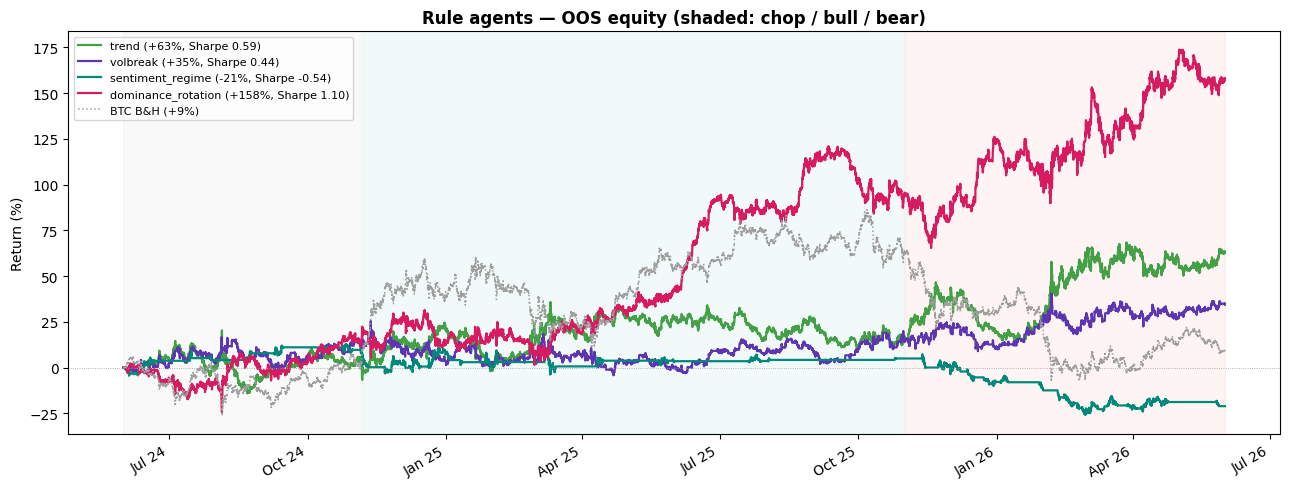

regime,bear,bull,chop
agent,,,
dominance_rotation,+32.0%,+65.9%,+13.1%
sentiment_regime,-24.8%,-1.6%,+9.7%
trend,+40.5%,+16.9%,+4.3%
volbreak,+17.4%,+3.0%,+11.9%


In [7]:
import matplotlib.pyplot as plt, matplotlib.dates as mdates
colours = {"trend": "#43A047", "volbreak": "#5E35B1",
           "sentiment_regime": "#00897B", "dominance_rotation": "#D81B60"}
fig, ax = plt.subplots(figsize=(13, 5))
for a in RULE_AGENTS:
    eq = out[a]["_eq_oos"]
    ax.plot(eq.index, (eq.values - 1) * 100, lw=1.6, color=colours[a],
            label=f"{a} ({eq.values[-1]-1:+.0%}, Sharpe {sharpe(eq.values):.2f})")
bh = (1 + df["close"].pct_change().fillna(0))[oos].cumprod()
ax.plot(bh.index, (bh.values / bh.values[0] - 1) * 100, lw=1.1, ls=":", color="#9E9E9E",
        label=f"BTC B&H ({bh.values[-1]/bh.values[0]-1:+.0%})")
for r, c in [("chop", "#9E9E9E"), ("bull", "#26A69A"), ("bear", "#EF5350")]:
    s, e = REGIME_DATES[r]; ax.axvspan(s, min(e, bh.index[-1]), alpha=0.06, color=c)
ax.axhline(0, color="#9E9E9E", lw=0.6, ls=":"); ax.set_ylabel("Return (%)"); ax.legend(fontsize=8)
ax.set_title("Rule agents — OOS equity (shaded: chop / bull / bear)", fontweight="bold")
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
fig.tight_layout(); plt.show()

reg = []
for a in RULE_AGENTS:
    eq = out[a]["_eq_oos"]
    for r in REGIMES:
        s, e = REGIME_DATES[r]; mseg = (eq.index >= s) & (eq.index <= e)
        if mseg.sum() < 24: continue
        seg = eq[mseg].values / eq[mseg].values[0]
        reg.append({"agent": a, "regime": r, "ret": f"{seg[-1]-1:+.1%}"})
pd.DataFrame(reg).pivot(index="agent", columns="regime", values="ret")